In [1]:
import numpy as np
import pandas as pd
import os
import sys
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
import country_converter as coco
import geopandas as gpd

parent_dir = os.path.abspath("..")
sys.path.insert(0, parent_dir)

import numpy as np
import pandas as pd

from experiments import utils
from package_name.evaluation import plots as eval_plots
from package_name.evaluation.utils import predict_clusters
from package_name.evaluation.metrics import compute_BSS_quantile_exceedance, compute_BSS_quantile_prediction, compute_BSS_clusters_target 
from package_name.model.utils import sampling, LossFactorsConfig
from package_name.training.trainer import VAETrainer, VAEConfig
from package_name.tuning.cross_validator import CrossValidator
from package_name.inference.predictor import VAEPredictor

import matplotlib.pyplot as plt
import plotly.express as px
plt.style.use("dark_background")



## Parameters

In [2]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
results_path = "results/energy/"
cluster_number = 4
original_dim = 575
pr_cluster_number = 4
batch_size = 128
epochs = 500


## Data loading and pre-processing

In [ ]:
# #create clusters for country-wise energy data
# path = "data/WON_country_wise.csv"

# df_in = pd.read_csv(path, comment="#")

# df_filtered = df_in.copy()
# df_filtered["Date"] = pd.to_datetime(df_filtered["Date"])
# df_filtered = df_filtered[(df_filtered["Date"].dt.year > 1980) & (df_filtered["Date"].dt.year < 2023)]
# df_filtered = df_filtered[df_filtered["Date"].dt.month.isin(extended_winter_months)]

# df_countries = df_filtered.drop(columns=["Date"])
# df_countries = df_countries.dropna(axis=1, how="all").reset_index(drop=True)

# df_norm, df_clusters = utils.cluster_country_wise(df_countries, cluster_number=pr_cluster_number, standardize=True)

# #df_clusters.to_csv("data/wind/WON_clusters_norm.csv")
# #df_norm.to_csv("data/wind/WON_country_wise_norm.csv")

In [3]:
# Get training data
z500 = utils.preprocess_dataset(filename ='data/era5_z500_daily_250_atlantic_1940_2022.nc',
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = 'extended europe',
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)

# Get training data labels
pr_labels = pd.read_csv('data/wind/WON_clusters_norm.csv')
pr_labels.columns = ['index', 'labels']
#pr_labels.drop(pr_labels.tail(1).index,inplace=True)

pr_labels['values']=[1]*len(pr_labels)
label_indices_pd = pd.pivot_table(pr_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values

## Visualise target clusters

In [18]:
#select days belonging to each cluster and calculate the mean of each cluster
df_cluster_means = pd.DataFrame(columns=df_norm.columns)
for i in range(4):
    cluster_i = df_norm[df_clusters["labels"] == i]
    cluster_i_mean = cluster_i.mean()
    df_cluster_means.loc[i] = cluster_i_mean

In [19]:
# TODO: turn this into a function
column_labels = df_norm.columns.astype(str).tolist()

plot_data_list = []
for cluster_id in range(4):
    df_temp = pd.DataFrame({
        'iso2_labels': column_labels,  
        'metric_value': df_cluster_means.loc[cluster_id].values,
        'cluster': f"K-means Cluster {cluster_id}" 
    })
    plot_data_list.append(df_temp)

df_plot = pd.concat(plot_data_list, ignore_index=True)

# Convert the ISO-2 labels column to ISO-3 strings
cc = coco.CountryConverter()
df_plot['iso3_labels'] = cc.convert(names=df_plot['iso2_labels'].tolist(), to='ISO3')

# Plot
fig = px.choropleth(
    df_plot,
    locations="iso3_labels",        
    locationmode="ISO-3",         
    color="metric_value",         
    hover_name="iso2_labels",    
    scope="europe",               
    facet_col="cluster",         
    color_continuous_scale=px.colors.sequential.Viridis, 
    title="European Energy Clusters"
)


fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) # Removes ugly "cluster=" prefix from subplot titles
fig.update_layout(
    margin={"r":10, "t":40, "l":10, "b":5},
    height=200, 
    width=600, 

    coloraxis_colorbar=dict(
        title="Wind CF anomaly",     
        thicknessmode="pixels",
        thickness=5,  
        orientation="h",          
        lenmode="fraction",
        len=0.5,              
        yanchor="middle",       
        y=-0.1
    )
)

fig.show()

## Define model

In [ ]:
config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,#8,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

loss_config = LossFactorsConfig(
    vae_reconstruction_loss_factor=1,
    vae_regularisation_loss_factor=1,
    target_prediction_loss_factor=1,
    cluster_target_regularisation_loss_factor=1,#5
    mixture_regularization_loss_factor=1,#2,
    dirichlet_loss_factor=0.5,#1
)

vae = VAETrainer(cfg=config,  path_to_save_weights=results_path, loss_factors=loss_config)
vae.compile()

history = vae.fit(
    X=z500.values,
    y=label_indices,
    epochs=epochs,
    batch_size=batch_size
)

vae.save_weights(results_path+'final_weights_'+str(cluster_number)+'.weights.h5')

Epoch 1/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - cluster_target_regularisation_loss: 0.1315 - mixture_regularization_loss: 3.0477 - reconstruction_loss: 521.3972 - target_prediction_loss: 5.8063 - total_loss: 539.3791 - vae_regularisation_loss: 8.9964 - val_cluster_target_regularisation_loss: 0.1998 - val_mixture_regularization_loss: 2.9813 - val_reconstruction_loss: 400.8519 - val_target_prediction_loss: 5.7413 - val_total_loss: 428.6017 - val_vae_regularisation_loss: 18.8273
Epoch 2/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - cluster_target_regularisation_loss: 0.2418 - mixture_regularization_loss: 2.9977 - reconstruction_loss: 284.3701 - target_prediction_loss: 5.7555 - total_loss: 316.2390 - vae_regularisation_loss: 22.8740 - val_cluster_target_regularisation_loss: 0.2227 - val_mixture_regularization_loss: 2.9563 - val_reconstruction_loss: 228.9998 - val_target_prediction_loss: 5.5956 - val_total_loss: 258.4570 - val_vae_regularisation_loss: 20.6826
Epoch 3/500
35/35 ━━━━━━━━━

## Plot training and validation losses

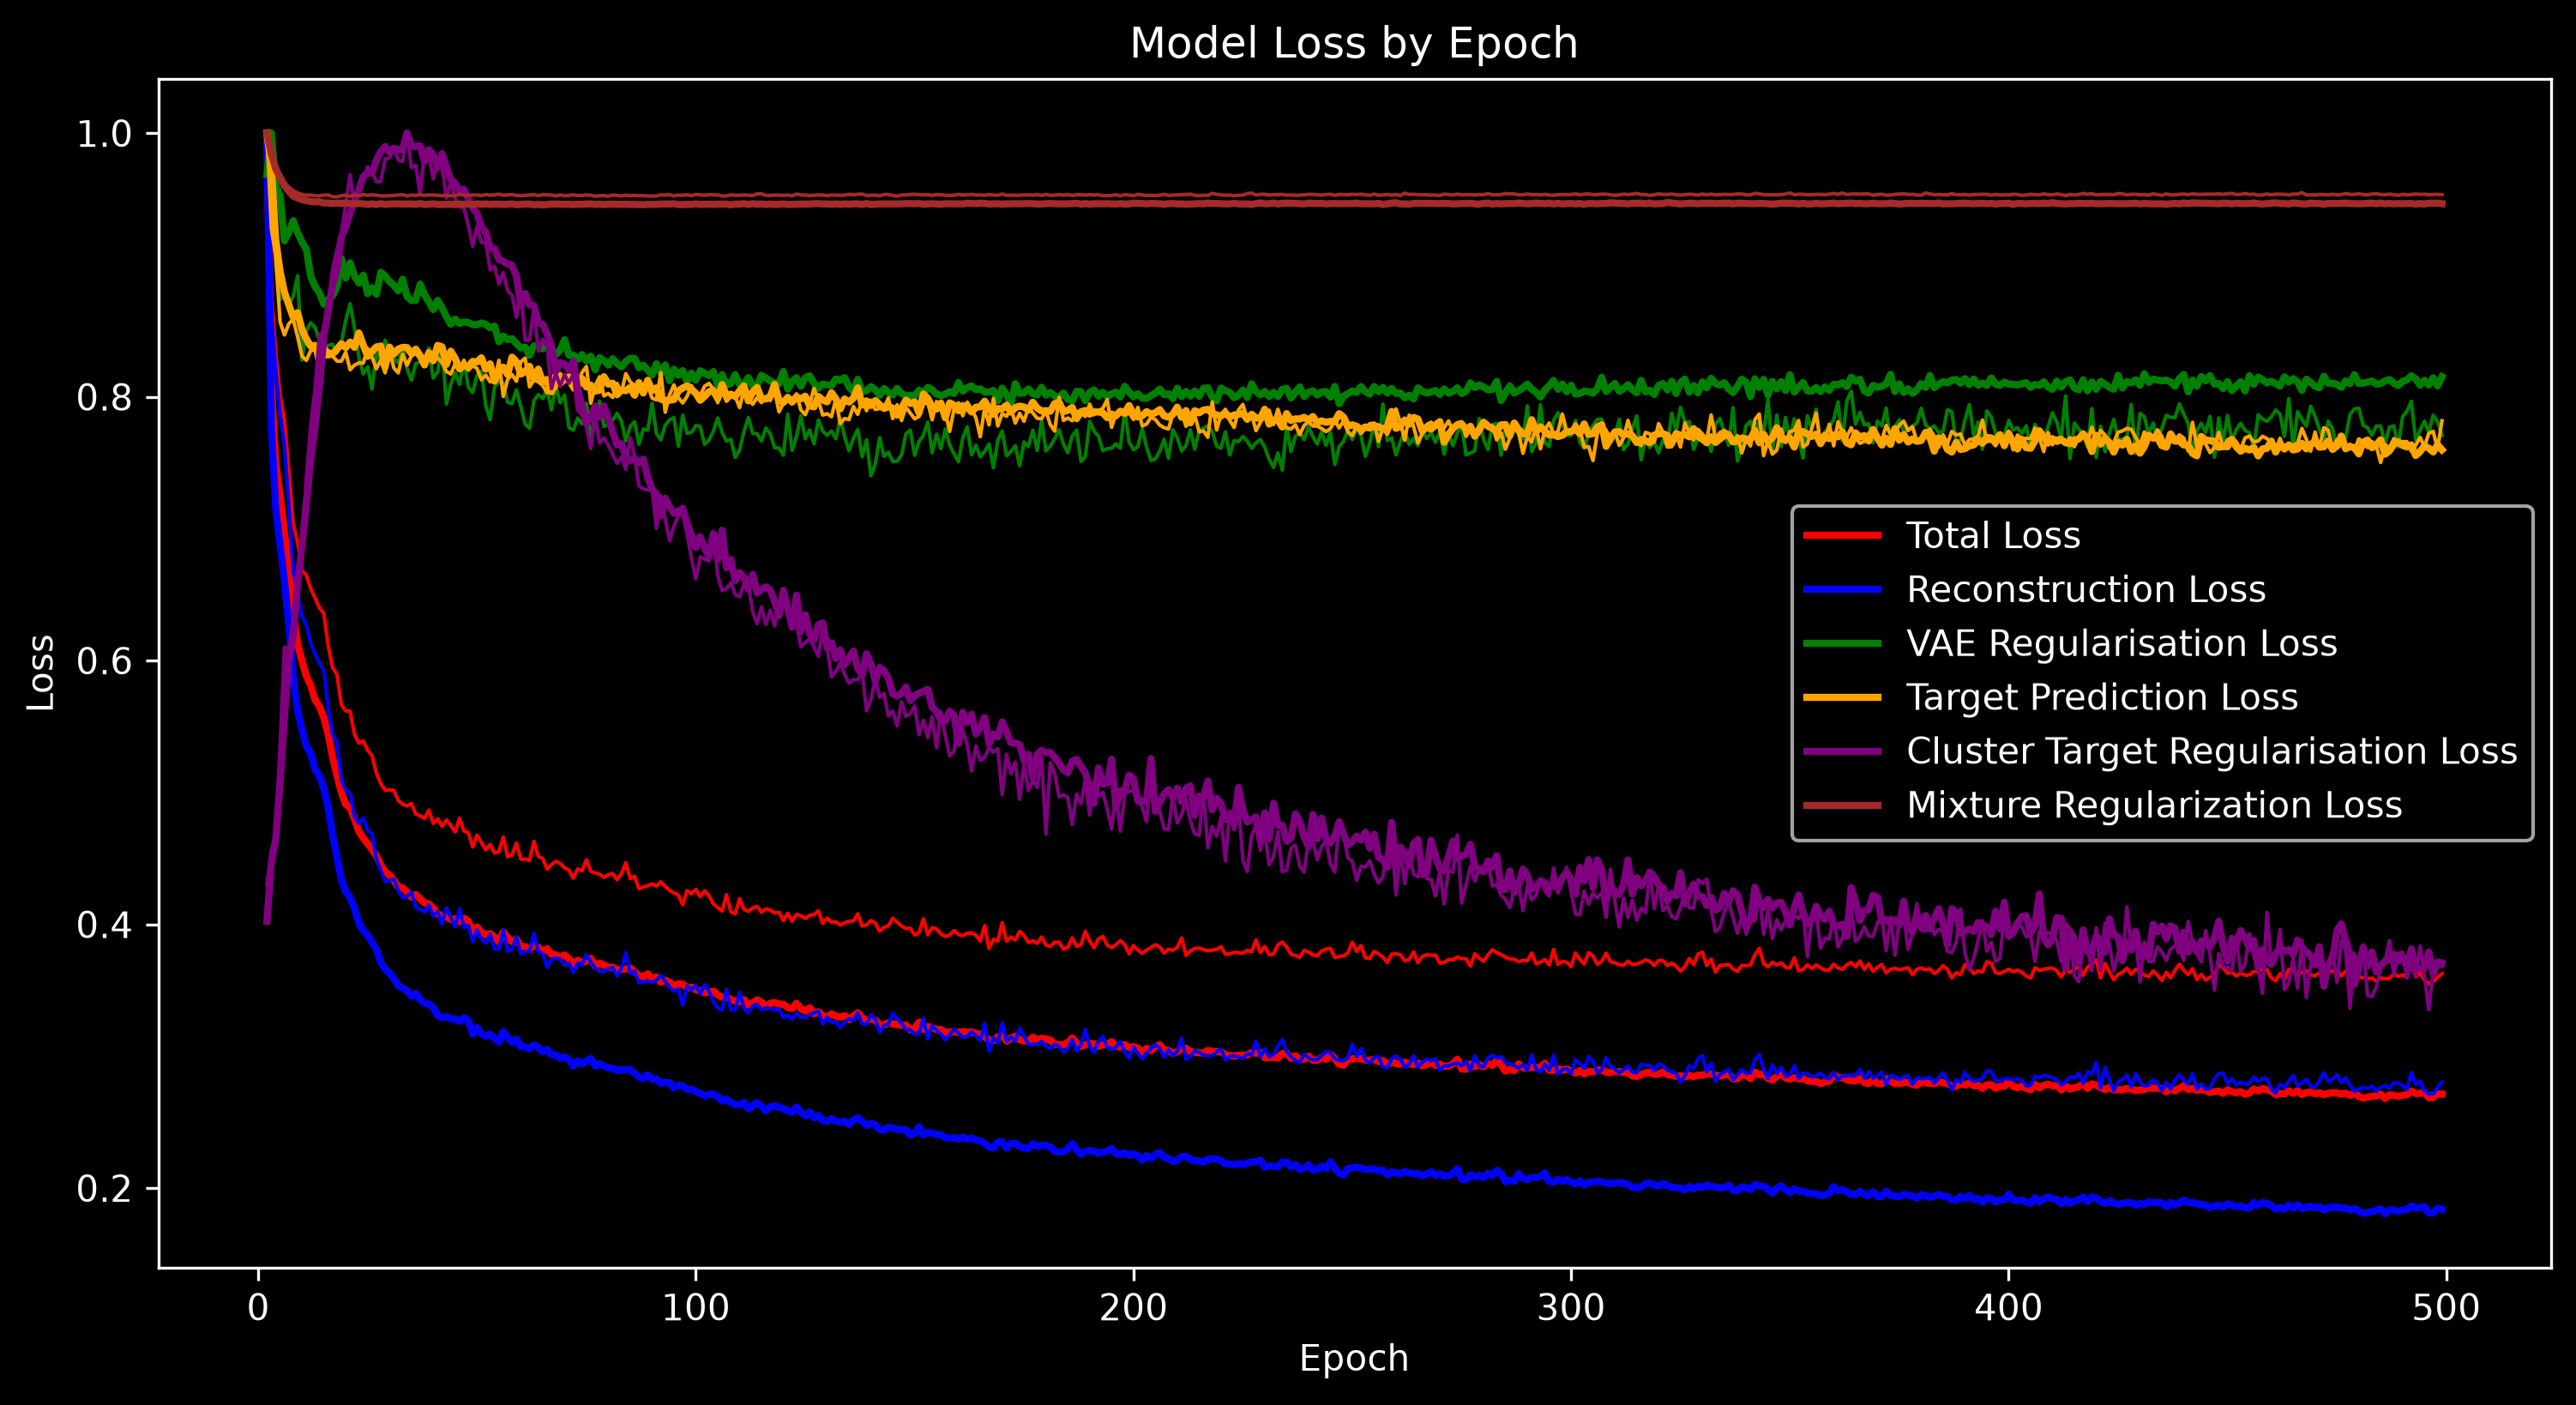

In [11]:
utils.plot_all_losses(history=history)

## Cross validation

In [12]:
cross_validator = CrossValidator(vae=vae,results_path=results_path,cluster_number=cluster_number,n_runs=5)
histories = cross_validator.run(X=z500.values,y=label_indices,epochs=epochs, batch_size=batch_size)

Epoch 1/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cluster_target_regularisation_loss: 0.2673 - mixture_regularization_loss: 3.0268 - reconstruction_loss: 479.8089 - target_prediction_loss: 6.3740 - total_loss: 503.0529 - vae_regularisation_loss: 13.5759 - val_cluster_target_regularisation_loss: 0.3730 - val_mixture_regularization_loss: 2.8874 - val_reconstruction_loss: 291.3034 - val_target_prediction_loss: 6.2038 - val_total_loss: 328.5574 - val_vae_regularisation_loss: 27.7897
Epoch 2/500
 1/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cluster_target_regularisation_loss: 0.4495 - mixture_regularization_loss: 2.8910 - reconstruction_loss: 303.0395 - target_prediction_loss: 6.2360 - total_loss: 342.5760 - vae_regularisation_loss: 29.9600

/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 56 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cluster_target_regularisation_loss: 0.3762 - mixture_regularization_loss: 2.8955 - reconstruction_loss: 248.9349 - target_prediction_loss: 5.7262 - total_loss: 280.2427 - vae_regularisation_loss: 22.3098 - val_cluster_target_regularisation_loss: 0.4070 - val_mixture_regularization_loss: 2.8903 - val_reconstruction_loss: 225.0593 - val_target_prediction_loss: 5.3333 - val_total_loss: 254.8645 - val_vae_regularisation_loss: 21.1746
Epoch 3/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cluster_target_regularisation_loss: 0.4770 - mixture_regularization_loss: 2.8754 - reconstruction_loss: 207.4571 - target_prediction_loss: 5.4457 - total_loss: 237.9991 - vae_regularisation_loss: 21.7439 - val_cluster_target_regularisation_loss: 0.5215 - val_mixture_regularization_loss: 2.8626 - val_reconstruction_loss: 189.9085 - val_target_prediction_loss: 5.4864 - val_total_loss: 219.9789 - val_vae_regularisation_loss: 21.1999
Epoch 4/500
35/35 ━━━━━━━━━━━━━━━━━━━━

In [11]:
number = 1

training_loss = histories[number].history['total_loss']
validation_loss = histories[number].history['val_total_loss']
utils.plot_losses(training_loss, validation_loss)

NameError: name 'histories' is not defined

## Visualize the clusters

In [4]:
cluster_number = 4

config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

In [ ]:
def make_plots(run_id):
    vae = VAEPredictor(cfg=config)
    vae.load_weights(results_path + f"final_weights_{vae.cfg.cluster_number}_{run_id}.weights.h5")
    eval_plots.plot_reordered_centers_and_odds_ratio(
        vae, z500, 0*z500)

    # fig_cluster_centers = eval_plots.plot_cluster_centers(
    #     vae,
    #     z500[0],
    #     plot_reordering=None,
    #     levels=np.arange(-2.0, 2.1, 0.25),
    # )

    # fig_empirical_cluster_centers = eval_plots.plot_empirical_cluster_centers(
    #     inputs_with_label,
    #     plot_reordering=label_reordering,
    #     levels=np.arange(-2.0, 2.1, 0.25),
    # )

In [6]:
make_plots(1)

TypeError: plot_reordered_centers_and_odds_ratio() missing 2 required positional arguments: 'inputs' and 'target_binary'

# old stuff (Nora)

In [23]:
X_all = z500.values.reshape(z500.values.shape[0], -1, order='F')
input = {
    "x": X_all,
    "dummy": np.ones((X_all.shape[0], 1)),
    "target": np.zeros((X_all.shape[0], vae.cfg.pr_cluster_number)),
}

In [24]:
encoded = vae.encode(input)
cluster_probs = encoded['clusters']['clusters_pred']
cluster_label = np.argmax(cluster_probs, axis=1)

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [25]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

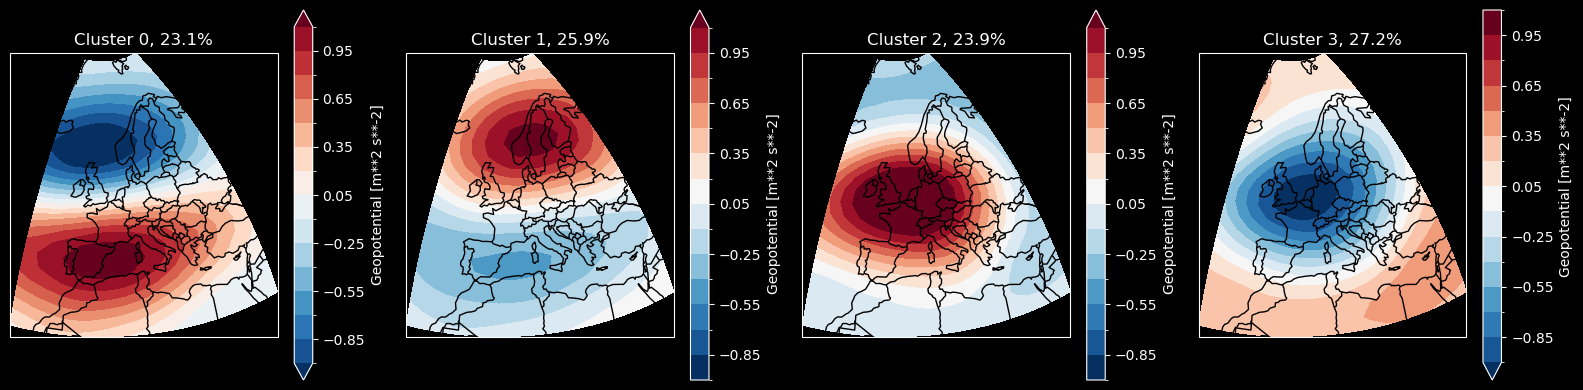

In [26]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

#order clusters by how often they occur in the data
label_counts = np.bincount(z500_with_label.label.values)
label_order = np.argsort(label_counts)[::-1]  # Sort in descending order


### Keep the same training / testing sets
utils.plot_cluster_centers(cluster_centers_empirical,
                           z500_with_label.label.values,
                           levels=np.arange(-1., 1.1, 0.15))

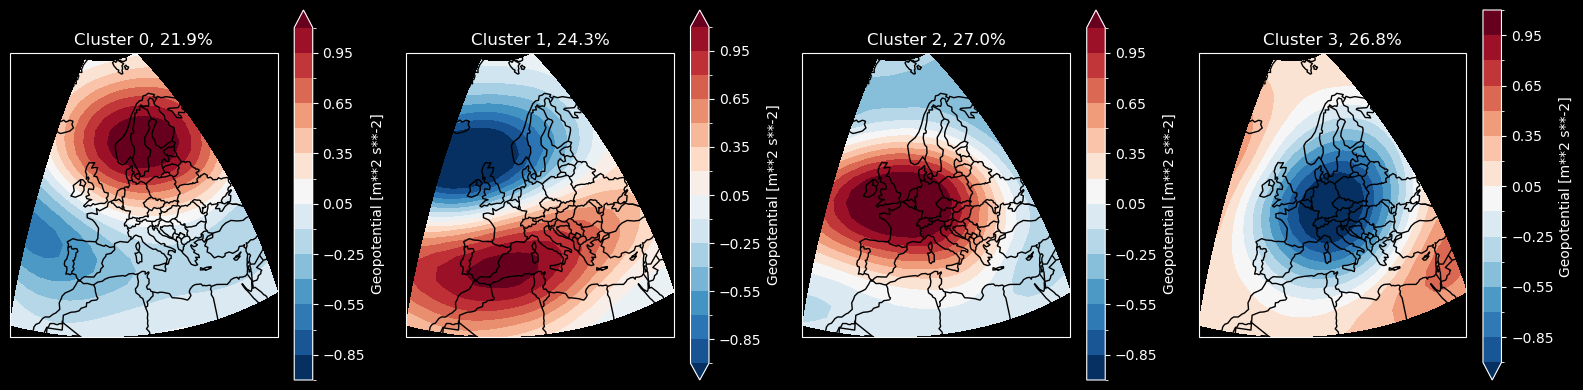

In [18]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

#order clusters by how often they occur in the data
label_counts = np.bincount(z500_with_label.label.values)
label_order = np.argsort(label_counts)[::-1]  # Sort in descending order


### Keep the same training / testing sets
utils.plot_cluster_centers(cluster_centers_empirical,
                           z500_with_label.label.values,
                           levels=np.arange(-1., 1.1, 0.15))

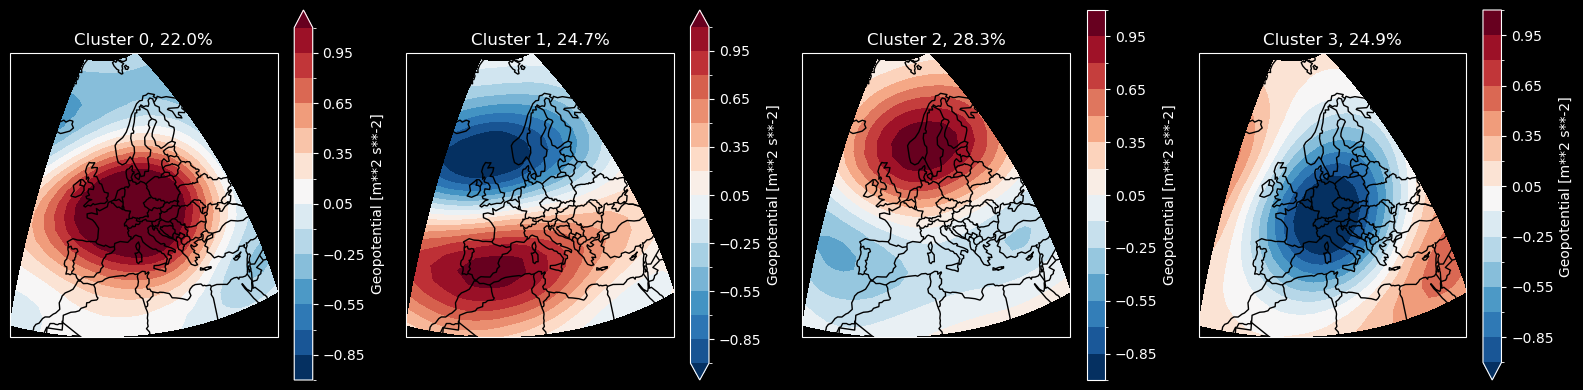

In [10]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

#order clusters by how often they occur in the data
label_counts = np.bincount(z500_with_label.label.values)
label_order = np.argsort(label_counts)[::-1]  # Sort in descending order


### Keep the same training / testing sets
utils.plot_cluster_centers(cluster_centers_empirical,
                           z500_with_label.label.values,
                           levels=np.arange(-1., 1.1, 0.15))

In [27]:
wind_energy_means = df_norm.groupby(z500_with_label.label.values).mean()

In [28]:
column_labels = df_norm.columns.astype(str).tolist()

plot_data_list = []
for cluster_id in range(cluster_number):
    df_temp = pd.DataFrame({
        'iso2_labels': column_labels,  
        'metric_value': wind_energy_means.loc[cluster_id].values,
        'cluster': f"Regime {cluster_id}" 
    })
    plot_data_list.append(df_temp)

df_plot = pd.concat(plot_data_list, ignore_index=True)

cc = coco.CountryConverter()

# Convert the ISO-2 labels column to ISO-3 strings
df_plot['iso3_labels'] = cc.convert(names=df_plot['iso2_labels'].tolist(), to='ISO3')

# Plot
fig = px.choropleth(
    df_plot,
    locations="iso3_labels",        
    locationmode="ISO-3",         
    color="metric_value",         
    hover_name="iso2_labels",    
    scope="europe",               
    facet_col="cluster",         
    color_continuous_scale=px.colors.sequential.Viridis, 
    title="Wind CF Clusters"
)


fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) 
fig.update_layout(
    margin={"r":10, "t":40, "l":10, "b":5},
    height=200, 
    width=600, 

    coloraxis_colorbar=dict(
        title="Wind CF anomaly",     # Label for the scale
        thicknessmode="pixels",
        thickness=5,  
        orientation="h",           # Thinner bar (default is usually 30)
        lenmode="fraction",
        len=0.5,                  # Takes up only 60% of the map height instead of 100%
        yanchor="middle",         # Centers it vertically
        y=-0.1
    )
)

fig.show()

## Evaluate clusters

In [29]:
BSS_clusters_target = compute_BSS_clusters_target(vae=vae, inputs=z500.values, targets_categorical=label_indices)

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [30]:
BSS_clusters_target

np.float64(0.17081549720579203)

In [31]:
#to get BSS_q_exceedance by country uncomment line 96 in _compute_brier_score in evaluation/metrics.py
BSS_exceedance = compute_BSS_quantile_exceedance(vae=vae, inputs=z500.values, targets=df_norm.values, q=0.9)

199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [32]:
BSS_exceedance

np.float64(0.051188164113167955)

In [ ]:
# BSS_clusters_target = compute_BSS_clusters_target(vae=vae, inputs=z500.values, targets_categorical=np.expand_dims(label_indices, axis=-1))


np.float64(0.05092325981396707)